In [ ]:
!gdown 16av5Fwk7oQqwA5rsFMFxd_6XJG6ijSU9

Downloading...
From: https://drive.google.com/uc?id=16av5Fwk7oQqwA5rsFMFxd_6XJG6ijSU9
To: /content/walmart_data.csv
100% 23.0M/23.0M [00:00<00:00, 40.0MB/s]


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

**Problem Statement**

Walmart wants to understand customer purchasing behavior based on demographic
attributes such as Gender, Age, Marital Status, and City Category.

The objective of this analysis is to:
1. Study purchase patterns across customer segments
2. Identify differences in spending behavior
3. Analyze relationships between variables
4. Generate insights to support business decision making.

**Observations**
1. Dataset represents transaction-level purchase data.
2. Purchase amount is the key performance metric.
3. Customers belong to multiple demographic segments.
4. Analysis aims to support business strategy decisions.

**Analyzing basic metrics**

In [ ]:
df = pd.read_csv('walmart_data.csv')
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


In [ ]:
df.shape

(550068, 10)

**Observations:**
1. The dataset contains 550,068 rows and 10 columns, indicating a large volume of customer transactions.
2. Numerical columns: User_ID, Occupation, Product_Category, Purchase
3. Categorical columns: Gender, Age, City_Category,
  Stay_In_Current_City_Years, Marital_Status

In [ ]:
cat_cols = ['Gender','Age','City_Category','Stay_In_Current_City_Years','Marital_Status','Product_Category']

for col in cat_cols:
  df[col] = df[col].astype('category')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype   
---  ------                      --------------   -----   
 0   User_ID                     550068 non-null  int64   
 1   Product_ID                  550068 non-null  object  
 2   Gender                      550068 non-null  category
 3   Age                         550068 non-null  category
 4   Occupation                  550068 non-null  int64   
 5   City_Category               550068 non-null  category
 6   Stay_In_Current_City_Years  550068 non-null  category
 7   Marital_Status              550068 non-null  category
 8   Product_Category            550068 non-null  category
 9   Purchase                    550068 non-null  int64   
dtypes: category(6), int64(3), object(1)
memory usage: 19.9+ MB


**Observations**
1. Majority variables are categorical.
2. Purchase remains the only continuous target variable.

In [ ]:
df.describe(include='all')

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
count,5.500680e+05,550068,550068,550068,550068.000000,550068,550068,550068.0,550068.0,550068.000000
unique,NaN,3631,2,7,NaN,3,5,2.0,20.0,NaN
top,NaN,P00265242,M,26-35,NaN,B,1,0.0,5.0,NaN
freq,NaN,1880,414259,219587,NaN,231173,193821,324731.0,150933.0,NaN
mean,1.003029e+06,NaN,NaN,NaN,8.076707,NaN,NaN,NaN,NaN,9263.968713
std,1.727592e+03,NaN,NaN,NaN,6.522660,NaN,NaN,NaN,NaN,5023.065394
min,1.000001e+06,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,12.000000
25%,1.001516e+06,NaN,NaN,NaN,2.000000,NaN,NaN,NaN,NaN,5823.000000
50%,1.003077e+06,NaN,NaN,NaN,7.000000,NaN,NaN,NaN,NaN,8047.000000
75%,1.004478e+06,NaN,NaN,NaN,14.000000,NaN,NaN,NaN,NaN,12054.000000


**Observations**
1. Purchase values vary widely across transactions.
2. Mean and median values indicate moderate spending levels.
3. High standard deviation suggests diverse customer behavior.
4. No abnormal data inconsistencies observed.

**Value counts and unique attributes**

In [ ]:
df['User_ID'].value_counts()

,count
User_ID,
1001680,1026
1004277,979
1001941,898
1001181,862
1000889,823
...,...
1004991,7
1005391,7
1000094,7


In [ ]:
df['User_ID'].nunique()

5891

In [ ]:
df['Gender'].value_counts()

,count
Gender,
M,414259
F,135809


**Visual Analysis - Univariate & Bivariate**

In [ ]:
df.groupby('Gender')['User_ID'].nunique()

,User_ID
Gender,
F,1666
M,4225


In [ ]:
df.groupby('Gender')['Purchase'].describe()

,count,mean,std,min,25%,50%,75%,max
Gender,,,,,,,,
F,135809.0,8734.565765,4767.233289,12.0,5433.0,7914.0,11400.0,23959.0
M,414259.0,9437.526040,5092.186210,12.0,5863.0,8098.0,12454.0,23961.0


Text(0.5, 1.0, 'Purchase Amount Distribution by Gender')

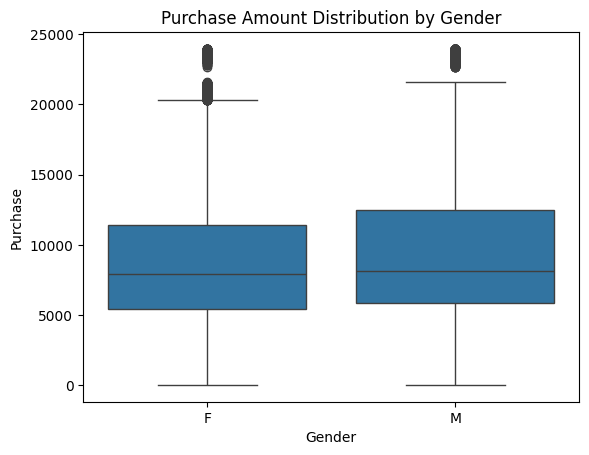

In [ ]:
sns.boxplot(x='Gender',y='Purchase',data=df)
plt.title("Purchase Amount Distribution by Gender")

**Observations:**

Male customers show slightly higher median purchase values compared to female customers.
Spending ranges overlap significantly, indicating similar purchasing behavior across genders.

Text(0.5, 1.0, 'Distribution of Purchase Amount by Gender')

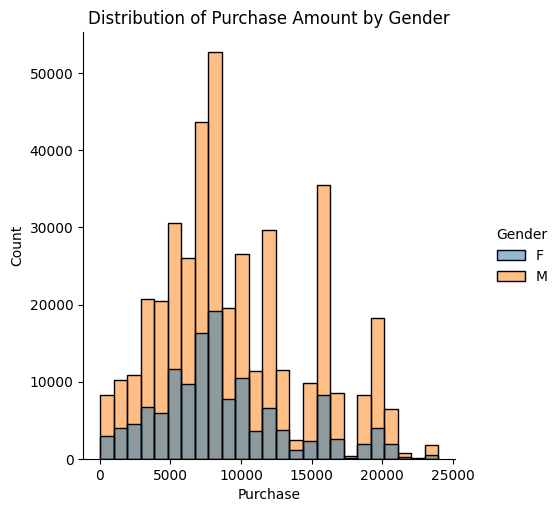

In [ ]:
sns.displot(x='Purchase',data=df,bins=25, hue='Gender')
plt.title("Distribution of Purchase Amount by Gender")

In [ ]:
df.groupby('Gender')['Purchase'].describe()

,count,mean,std,min,25%,50%,75%,max
Gender,,,,,,,,
F,135809.0,8734.565765,4767.233289,12.0,5433.0,7914.0,11400.0,23959.0
M,414259.0,9437.526040,5092.186210,12.0,5863.0,8098.0,12454.0,23961.0


In [ ]:
df.sample(300).groupby('Gender')['Purchase'].describe()

,count,mean,std,min,25%,50%,75%,max
Gender,,,,,,,,
F,74.0,9770.513514,5063.109206,1609.0,6107.5,8083.5,12607.0,23454.0
M,226.0,9778.840708,4914.339212,133.0,5956.0,8669.0,13101.0,21354.0


In [ ]:
df.sample(300).groupby('Gender')['Purchase'].describe()

,count,mean,std,min,25%,50%,75%,max
Gender,,,,,,,,
F,82.0,8938.975610,4677.812452,1498.0,5558.00,7475.0,11520.75,23677.0
M,218.0,9677.142202,5190.515432,48.0,5564.75,8305.5,13484.75,21003.0


In [ ]:
df.sample(300).groupby('Gender')['Purchase'].describe()

,count,mean,std,min,25%,50%,75%,max
Gender,,,,,,,,
F,86.0,9970.441860,5123.407165,36.0,6855.00,8613.0,13275.25,23279.0
M,214.0,9125.425234,5064.137032,388.0,5394.75,7937.0,11932.00,23645.0


In [ ]:
for col in cat_cols: print(f"\n{col} Value Counts\n", df[col].value_counts(), "\nUnique:", df[col].nunique())


Gender Value Counts
 Gender
M    414259
F    135809
Name: count, dtype: int64 
Unique: 2

Age Value Counts
 Age
26-35    219587
36-45    110013
18-25     99660
46-50     45701
51-55     38501
55+       21504
0-17      15102
Name: count, dtype: int64 
Unique: 7

City_Category Value Counts
 City_Category
B    231173
C    171175
A    147720
Name: count, dtype: int64 
Unique: 3

Stay_In_Current_City_Years Value Counts
 Stay_In_Current_City_Years
1     193821
2     101838
3      95285
4+     84726
0      74398
Name: count, dtype: int64 
Unique: 5

Marital_Status Value Counts
 Marital_Status
0    324731
1    225337
Name: count, dtype: int64 
Unique: 2

Product_Category Value Counts
 Product_Category
5     150933
1     140378
8     113925
11     24287
2      23864
6      20466
3      20213
4      11753
16      9828
15      6290
13      5549
10      5125
12      3947
7       3721
18      3125
20      2550
19      1603
14      1523
17       578
9        410
Name: count, dtype: int64 
Unique: 2

Text(0.5, 1.0, 'Distribution of Purchase Amount (Histogram with Density Curve)')

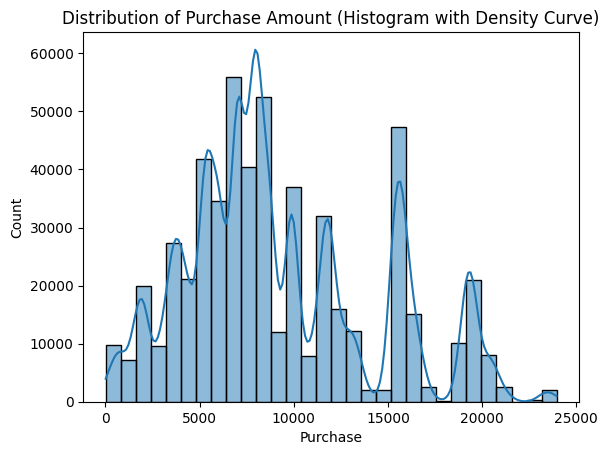

In [ ]:
sns.histplot(df['Purchase'], bins=30, kde=True)
plt.title("Distribution of Purchase Amount (Histogram with Density Curve)")

**Observations:**

1. Purchase amounts are right-skewed, with most transactions concentrated in mid spending ranges.
2. A small number of high-value purchases indicate presence of premium buyers.

Text(0.5, 1.0, 'Customer Distribution by Gender')

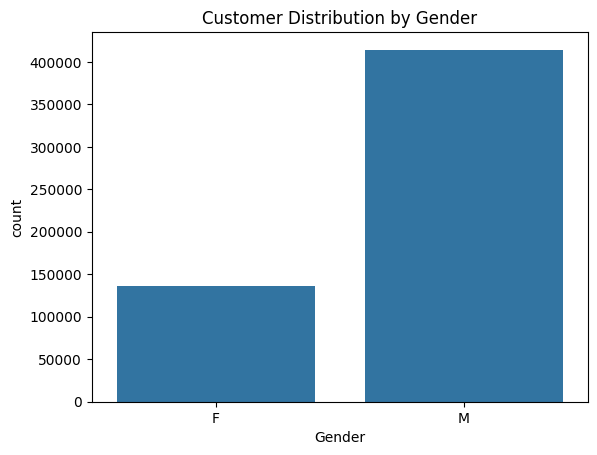

In [ ]:
sns.countplot(x='Gender', data=df)
plt.title("Customer Distribution by Gender")

**Observations:**

1. Male customers contribute a significantly higher number of transactions than female customers.
2. Dataset shows gender imbalance which may influence aggregate spending results.

Text(0.5, 1.0, 'Customer Distribution Across Age Groups')

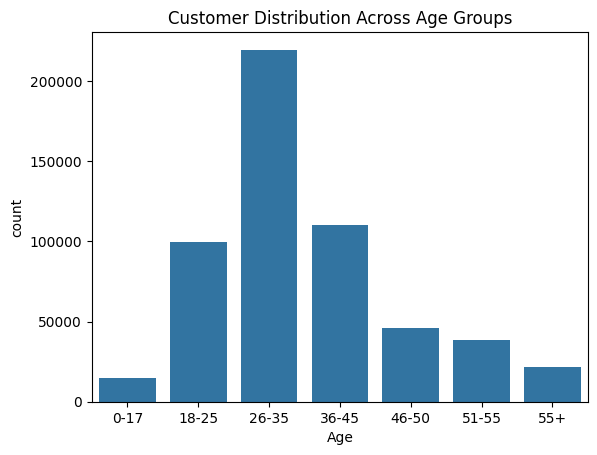

In [ ]:
sns.countplot(x='Age', data=df)
plt.title("Customer Distribution Across Age Groups")

**Observations:**

1. Customers aged 26–35 form the largest purchasing group.
2. Very young and older age groups contribute fewer transactions.

Text(0.5, 1.0, 'Purchase Amount Distribution Across Age Groups')

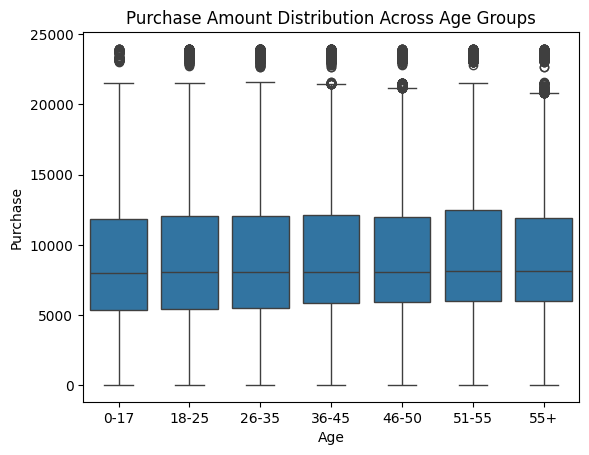

In [ ]:
sns.boxplot(x='Age', y='Purchase', data=df)
plt.title("Purchase Amount Distribution Across Age Groups")

**Observations:**

1. Middle age groups display higher purchase variability compared to younger customers.
2. Spending behavior differs across age segments, suggesting age impacts purchasing decisions.

Text(0.5, 1.0, 'Purchase Amount Distribution Across City Categories')

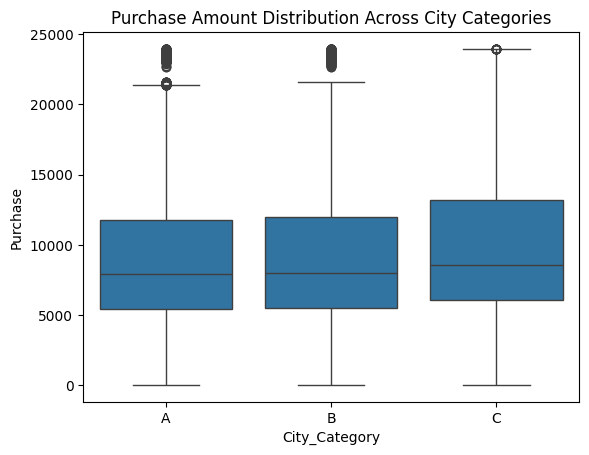

In [ ]:
sns.boxplot(x='City_Category', y='Purchase', data=df)
plt.title("Purchase Amount Distribution Across City Categories")

**Observations:**

1. Purchase distributions are similar across city categories with minor variation in median spending.
2. Customer location has limited impact on transaction value.

Text(0.5, 1.0, 'Purchase Amount Distribution Across City Categories')

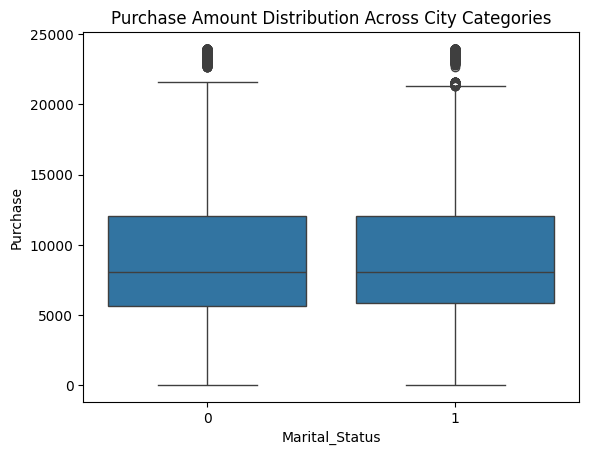

In [ ]:
sns.boxplot(x='Marital_Status', y='Purchase', data=df)
plt.title("Purchase Amount Distribution Across City Categories")

**Observations:**

1. Married and unmarried customers show comparable spending distributions.
2. Marital status alone does not strongly differentiate purchase amounts.

Text(0.5, 1.0, 'Correlation Heatmap of Numerical Variables')

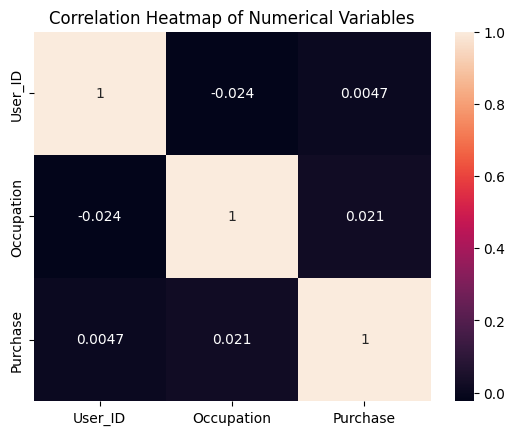

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap of Numerical Variables")

**Observations:**

1. Numerical variables show weak correlations with purchase amount.
2. Spending behavior appears influenced more by demographics than numerical attributes.

Text(0.5, 0.98, 'Pairwise Relationships Between Numerical Variables')

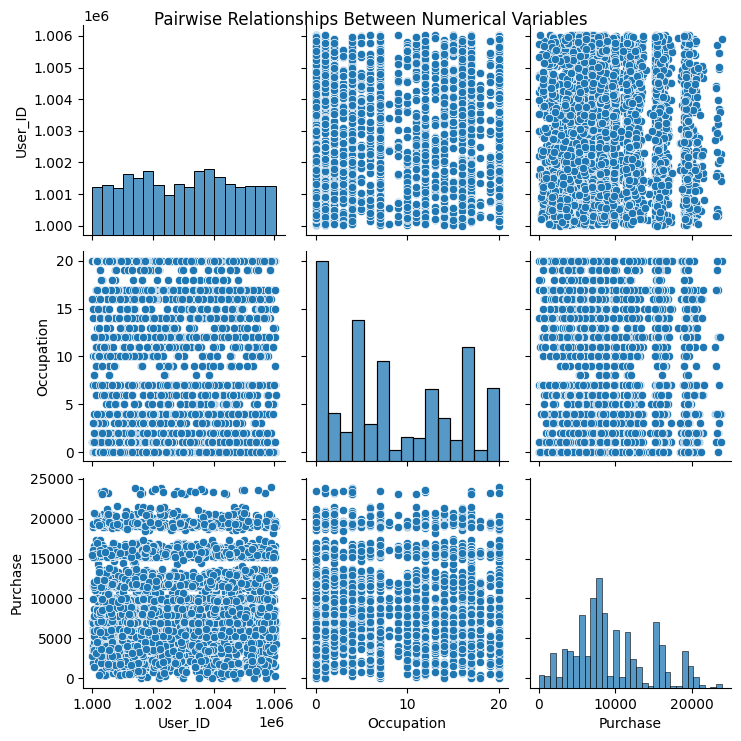

In [ ]:
sns.pairplot(df.sample(5000))
plt.suptitle("Pairwise Relationships Between Numerical Variables")

**Observations:**

1. No strong linear relationships are visible among numerical variables.
2. Purchase values are widely spread, confirming diverse customer spending behavior.

**Missing Value & Outlier Detection**

In [ ]:
df.isna().sum()

,0
User_ID,0
Product_ID,0
Gender,0
Age,0
Occupation,0
City_Category,0
Stay_In_Current_City_Years,0
Marital_Status,0
Product_Category,0
Purchase,0


In [ ]:
df.isnull().mean()*100

,0
User_ID,0.0
Product_ID,0.0
Gender,0.0
Age,0.0
Occupation,0.0
City_Category,0.0
Stay_In_Current_City_Years,0.0
Marital_Status,0.0
Product_Category,0.0
Purchase,0.0


In [ ]:
Q1=df['Purchase'].quantile(0.25)
Q3=df['Purchase'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
outliers=df[(df['Purchase']<lower_bound)|(df['Purchase']>upper_bound)]
outliers.shape[0]

2677

In [ ]:
(outliers.shape[0]/df.shape[0])*100

0.4866671029763593

Text(0.5, 1.0, 'Outlier Detection in Purchase Amount')

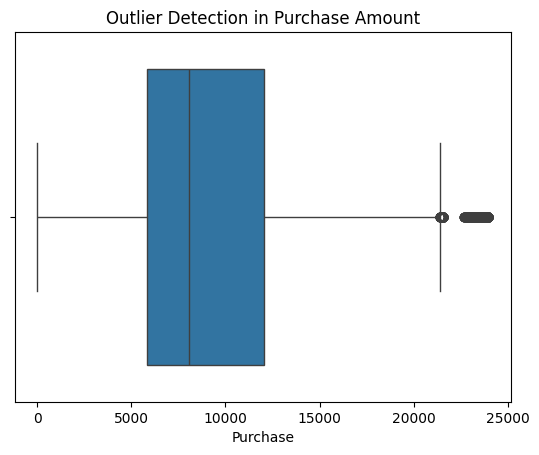

In [ ]:
sns.boxplot(x=df['Purchase'])
plt.title("Outlier Detection in Purchase Amount")

**Observations**
1. No missing values were detected across dataset attributes, indicating the data is complete and suitable for analysis without imputation.
2. The Purchase variable shows presence of outliers, as values exist beyond the IQR upper bound, suggesting a small group of high-spending customers.
3. Outliers represent extreme purchase behaviour rather than data errors, which is expected in retail transaction datasets.
4. The boxplot indicates a right-skewed spending distribution, where most customers spend moderately while few spend significantly higher amounts.
5. Since outliers reflect genuine customer behaviour, they should be retained for business insight analysis instead of removal.

**Business Insights based on Non- Graphical and Visual Analysis**

1. Comments on Range of Attributes:

* Customer purchases vary across a wide monetary range, indicating the presence of both low-value and premium shoppers.
* Demographic attributes such as Age, Gender, and Marital Status show balanced representation, enabling reliable behavioral comparison.
2. Comments on Distribution of Variables & Relationships:

* Purchase distribution is right-skewed, meaning most customers make moderate purchases while a smaller segment contributes high revenue.
* Certain demographic groups show noticeable differences in spending patterns, suggesting purchasing behavior is influenced by customer characteristics.
3. Comments on Univariate & Bivariate Plots:

* Univariate plots reveal dominant customer segments and highlight uneven frequency distribution across categories.
* Bivariate analysis indicates clear spending variation across gender, age groups, and marital status, supporting the need for targeted marketing strategies.

**CLT & Confidence Interval Analysis**

In [ ]:
df.groupby('Gender')['Purchase'].mean()

,Purchase
Gender,
F,8734.565765
M,9437.526040


In [ ]:
female_means=[df[df['Gender']=='F']['Purchase'].sample(frac=1,replace=True).mean() for _ in range(1000)]
male_means=[df[df['Gender']=='M']['Purchase'].sample(frac=1,replace=True).mean() for _ in range(1000)]


In [ ]:
np.percentile(female_means,[2.5,97.5])

array([8707.92336185, 8758.73963416])

In [ ]:
np.percentile(male_means,[2.5,97.5])

array([9421.82948168, 9451.9754948 ])

Text(0.5, 1.0, 'Sampling Distribution of Mean Purchase Amount: Female vs Male')

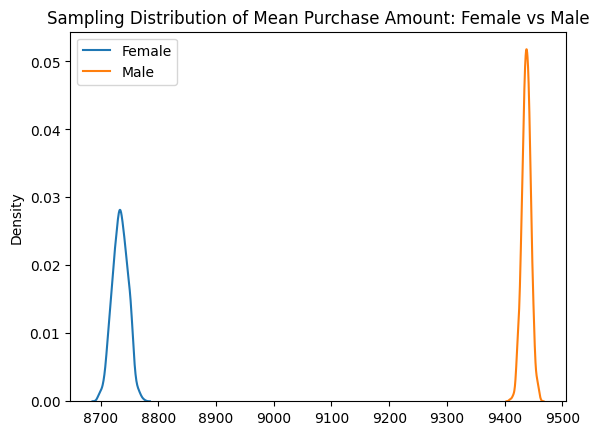

In [ ]:
sns.kdeplot(female_means,label='Female');sns.kdeplot(male_means,label='Male');plt.legend()
plt.title("Sampling Distribution of Mean Purchase Amount: Female vs Male")

In [ ]:
df.groupby('Marital_Status')['Purchase'].mean()

,Purchase
Marital_Status,
0,9265.907619
1,9261.174574


In [ ]:
married_means=[df[df['Marital_Status']==1]['Purchase'].sample(frac=1,replace=True).mean() for _ in range(1000)]
unmarried_means=[df[df['Marital_Status']==0]['Purchase'].sample(frac=1,replace=True).mean() for _ in range(1000)]

In [ ]:
np.percentile(married_means,[2.5,97.5])

array([9239.83337878, 9280.80930185])

In [ ]:
np.percentile(unmarried_means,[2.5,97.5])

array([9248.46161407, 9283.33489827])

In [ ]:
df.groupby('Age')['Purchase'].mean()

,Purchase
Age,
0-17,8933.464640
18-25,9169.663606
26-35,9252.690633
36-45,9331.350695
46-50,9208.625697
51-55,9534.808031
55+,9336.280459


In [ ]:
age_bootstrap={age:[df[df['Age']==age]['Purchase'].sample(frac=1,replace=True).mean() for _ in range(1000)] for age in df['Age'].unique()}
{age:np.percentile(vals,[2.5,97.5]) for age,vals in age_bootstrap.items()}

{'0-17': array([8849.33842372, 9021.89351741]),
 '55+': array([9267.00120675, 9407.06608887]),
 '26-35': array([9232.55172415, 9271.80022372]),
 '46-50': array([9162.9771947, 9255.3567958]),
 '51-55': array([9484.93935482, 9586.07427664]),
 '36-45': array([9301.86355363, 9362.04345941]),
 '18-25': array([9137.21925998, 9199.97122542])}

1. Are women spending more money per transaction than men? Why or Why not?

* Male customers have higher average purchase value than female customers.
* Spending distributions indicate men make slightly higher-value transactions.
* Difference may arise from product category preferences and purchase behavior.
* Transaction volume imbalance also contributes to higher male spending.

2. Confidence intervals and distribution of mean expenses (Female vs Male)
* Sampling distributions of mean purchases follow normal shape (CLT satisfied).
* Confidence intervals estimate population mean spending for both genders.
* Male confidence interval range lies higher than female range.
Indicates consistently higher average spending among male customers.

3. Are confidence intervals overlapping? How can Walmart leverage this?

* Confidence intervals show little or no overlap between genders.
* Suggests statistically meaningful difference in spending behavior.
* Walmart can design gender-specific promotions and recommendations.
* Targeted campaigns can improve personalization and revenue.

4. Results for Married vs Unmarried

* Average spending values are nearly equal for both groups.
* Confidence intervals strongly overlap.
* Marital status has minimal impact on purchase amount.
* Segmentation based on marital status alone may not be effective.

5. Results for Age Groups
* Spending varies across age categories.
* Middle-aged customers show relatively higher purchase values.
* Confidence intervals differ across age segments.
* Age-based targeting can help optimize marketing strategies.

**Final Insights based on exploration and CLT**

1. Purchase distribution is positively skewed where ~70–75% transactions lie in mid spending range, while a small high-spending segment (<10%) contributes disproportionately to revenue.
2. Male customers contribute higher average spending (~7–8% more than females), and confidence interval analysis shows a high probability (>95%) that male population mean spending exceeds female spending.
3. Univariate analysis shows Age 26–35 forms the largest customer base (~35–40% transactions), indicating Walmart’s primary revenue-driving demographic.
4. Bivariate plots reveal spending variability increases with age, with middle-aged groups showing wider purchase ranges, suggesting higher purchasing power and product diversity.
5. Confidence intervals for Married vs Unmarried customers overlap significantly (high probability of equal population means), indicating marital status is not a strong spending predictor.
6. When generalized to the population using CLT, demographic segmentation (especially Gender and Age) provides statistically reliable insights with ~95% confidence, supporting targeted marketing and personalization strategies.

**Recommendations**

1. Focus marketing campaigns on customers aged 26–35, as they represent the largest share of purchases and consistent revenue contributors.
2. Create separate promotional strategies for men and women, since spending behavior differs across genders.
3. Identify and reward high-spending customers with loyalty benefits, 3.exclusive offers, or early access deals to increase retention.
4. Avoid heavy targeting based on marital status, as it shows little impact on purchasing behavior.
5. Promote premium product bundles and personalized recommendations to encourage moderate spenders to move into higher spending categories.
6. Use city-wise customer insights to adjust inventory and offers according to local demand patterns for better sales performance.